# Dataset Description
2 Data Folders - EEG_raw and Smoothed EEG

### EEG_raw
- Contains raw EEG of 15 participants taken over 3 sessions.
- Each session has 15 .mat files
- Each .mat file have 24 Trials i.e 24 eeg arrays.
- Total number of EEG samples - 15 x 3 x 24 (participants x sessions x trials)
- Length of each EEG sample varies from 30000 - 50000. i.e 30s - 50s (fs = 1000Hz)
- Each EEG sample has 62 channels.

### Smoothed EEG
- Raw EEG data is downsampled to 200Hz and Filtered
- Does not contain Downsampled and filtered Data.
- Contains only Features like PSD, DE, MA etc.

### Questions
- Paper is ambiguous about Methodology. Are they using Smoothed Data. Or are they using Raw Data with downsampling, filtereing and extracting features.
- Are they using full length raw data or are they downsampling?
- If we use Smoothed Data, it is good quality but we wont be able to extract more features.

## Experiments To Do
- Use Raw EEG, downsample, filter, extract features mentioned in the paper.
- Use Raw EEG Data, dont downsample, segment into epochs, extract features.
- Use Feature selection techniques like PCA, AAFST(paper algo)
- Use Smoothed EEG Data directly no feature extraction.

## Instructions to Load Data From Kaggle
Follow This Tutorial
https://www.youtube.com/watch?v=7Z0s-XDXR1E

**NOTE**
For Kaggle API https://www.kaggle.com/settings
Do not use API Token. Create Legacy API KEY

In [ ]:
!pip install kaggle --quiet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Has to be run Everytime
!rm -rf ~/.kaggle
!mkdir ~/.kaggle
!cp /content/drive/MyDrive/Kaggle_API/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Has to be Run Everytime
!kaggle datasets download phhasian0710/seed-iv/
! unzip seed-iv.zip

Dataset URL: https://www.kaggle.com/datasets/phhasian0710/seed-iv/versions/
License(s): unknown
100% 13.7G/13.7G [05:58<00:00, 41.1MB/s]

Archive:  seed-iv.zip
  inflating: Channel Order.xlsx      
  inflating: ReadMe.txt              
  inflating: eeg_feature_smooth/1/10_20151014.mat  
  inflating: eeg_feature_smooth/1/11_20150916.mat  
  inflating: eeg_feature_smooth/1/12_20150725.mat  
  inflating: eeg_feature_smooth/1/13_20151115.mat  
  inflating: eeg_feature_smooth/1/14_20151205.mat  
  inflating: eeg_feature_smooth/1/15_20150508.mat  
  inflating: eeg_feature_smooth/1/1_20160518.mat  
  inflating: eeg_feature_smooth/1/2_20150915.mat  
  inflating: eeg_feature_smooth/1/3_20150919.mat  
  inflating: eeg_feature_smooth/1/4_20151111.mat  
  inflating: eeg_feature_smooth/1/5_20160406.mat  
  inflating: eeg_feature_smooth/1/6_20150507.mat  
  inflating: eeg_feature_smooth/1/7_20150715.mat  
  inflating: eeg_feature_smooth/1/8_20151103.mat  
  inflating: eeg_feature_smooth/1/9_20151028

## Loading a single .mat File

In [ ]:
import scipy.io as sio
import glob

mat = sio.loadmat("/content/eeg_raw_data/1/14_20151205.mat")

# Get all trial keys
trial_keys = sorted([k for k in mat.keys() if k.endswith(tuple([str(i) for i in range(1, 25)]))])
print(trial_keys)  # check key names

trial1 = mat[trial_keys[0]]
print(trial1.shape)

['zjd_eeg1', 'zjd_eeg10', 'zjd_eeg11', 'zjd_eeg12', 'zjd_eeg13', 'zjd_eeg14', 'zjd_eeg15', 'zjd_eeg16', 'zjd_eeg17', 'zjd_eeg18', 'zjd_eeg19', 'zjd_eeg2', 'zjd_eeg20', 'zjd_eeg21', 'zjd_eeg22', 'zjd_eeg23', 'zjd_eeg24', 'zjd_eeg3', 'zjd_eeg4', 'zjd_eeg5', 'zjd_eeg6', 'zjd_eeg7', 'zjd_eeg8', 'zjd_eeg9']
(62, 33601)


# Data Loading

In [ ]:
import os
import numpy as np
import scipy.io
import scipy.signal
from scipy.stats import skew, kurtosis
from collections import Counter

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────

DATA_ROOT = "/content/eeg_raw_data"
ORIG_SFREQ     = 1000   # Original sampling rate (Hz)
TARGET_SFREQ   = 200    # Downsample to 200 Hz
EPOCH_SAMPLES  = 800    # Samples per epoch at 200 Hz
SESSIONS       = [1, 2, 3]
N_PARTICIPANTS = 15
N_TRIALS       = 24

SESSION_LABELS = {
    1: [1, 2, 3, 0, 2, 0, 0, 1, 0, 1, 2, 1, 1, 1, 2, 3, 2, 2, 3, 3, 0, 3, 0, 3],
    2: [2, 1, 3, 0, 0, 2, 0, 2, 3, 3, 2, 3, 2, 0, 1, 1, 2, 1, 0, 3, 0, 1, 3, 1],
    3: [1, 2, 2, 1, 3, 3, 3, 1, 1, 2, 1, 0, 2, 3, 3, 0, 2, 3, 0, 0, 2, 0, 1, 0],
}

BANDS = {
    "delta": (0.5, 4),
    "theta": (4,   8),
    "alpha": (8,  13),
    "beta":  (13, 30),
    "gamma": (30, 75),
}

In [ ]:
def downsample(eeg, orig_sfreq, target_sfreq):
    """Downsample EEG from orig_sfreq to target_sfreq. Shape: (62, S)"""
    factor = orig_sfreq // target_sfreq
    return eeg[:, ::factor]   # Simple decimation

def bandpass_filter(eeg, lowcut=0.5, highcut=75, sfreq=TARGET_SFREQ):
    """Bandpass filter each channel. Shape in/out: (62, S)"""
    nyq = sfreq / 2
    b, a = scipy.signal.butter(4, [lowcut / nyq, highcut / nyq], btype="band")
    return scipy.signal.filtfilt(b, a, eeg, axis=1)

In [ ]:
def segment_into_epochs(eeg, epoch_samples=800, n_epochs=64):
    """Slide a window to extract exactly 64 overlapping epochs."""
    n_channels, n_samples = eeg.shape

    if n_samples < epoch_samples:
        return None

    max_start = n_samples - epoch_samples
    stride = max(1, max_start // (n_epochs - 1))

    starts = [i * stride for i in range(n_epochs)]
    # Trim to only starts that fit
    starts = [s for s in starts if s + epoch_samples <= n_samples]

    epochs = np.stack([eeg[:, s:s + epoch_samples] for s in starts], axis=0)
    return epochs   # (n_epochs, 62, 800)


In [ ]:
def bandpass_for_band(signal_1d, low, high, sfreq=TARGET_SFREQ):
    nyq = sfreq / 2
    b, a = scipy.signal.butter(4, [low / nyq, high / nyq], btype="band")
    return scipy.signal.filtfilt(b, a, signal_1d)

In [ ]:
def extract_features_one_epoch(epoch):
    """
    Extract features from a single epoch.
    Input: epoch of shape (62, 800)
    Output: 1D feature vector of length 62 × 19 = 1178
    """
    n_channels = epoch.shape[0]
    features = []

    # Compute PSD once for all channels using Welch's method
    freqs, psd = scipy.signal.welch(epoch, fs=TARGET_SFREQ, nperseg=256, axis=1)
    # psd shape: (62, n_freqs)

    for ch in range(n_channels):
        sig = epoch[ch]          # (800,)
        ch_psd = psd[ch]         # (n_freqs,)
        ch_feats = []

        # ── Time Domain (4 features) ──
        ch_feats.append(np.mean(sig))                    # Mean
        ch_feats.append(np.var(sig))                     # Variance
        ch_feats.append(np.max(sig) - np.min(sig))       # Amplitude
        ch_feats.append(float(skew(sig)))                # Skewness
        ch_feats.append(float(kurtosis(sig)))

        # Hjorth Mobility
        diff1 = np.diff(sig)
        mobility = np.sqrt(np.var(diff1) / (np.var(sig) + 1e-10))
        ch_feats.append(mobility)

        # ── Frequency Domain ──
        band_powers = {}
        for band_name, (low, high) in BANDS.items():
            idx = np.where((freqs >= low) & (freqs <= high))[0]
            band_psd = ch_psd[idx]

            # PSD per band — mean power in band (5 features)
            band_powers[band_name] = np.mean(band_psd)
            ch_feats.append(band_powers[band_name])

        # Peak Power (1 feature) — max PSD value across all freqs
        ch_feats.append(np.max(ch_psd))

        # Band Power — total power via Simpson integration (4 features, exclude gamma)
        for band_name in ["delta", "theta", "alpha", "beta"]:
            low, high = BANDS[band_name]
            idx = np.where((freqs >= low) & (freqs <= high))[0]
            bp = scipy.integrate.simpson(ch_psd[idx], x=freqs[idx])
            ch_feats.append(bp)

        ch_feats.append(band_powers["alpha"] / (band_powers["theta"] + 1e-10))  # alpha/theta
        ch_feats.append(band_powers["beta"]  / (band_powers["alpha"] + 1e-10))  # beta/alpha
        ch_feats.append(band_powers["theta"] / (band_powers["beta"]  + 1e-10))  # theta/beta


        # Differential Entropy — log(var(bandpass signal)) per band (5 features)
        for band_name, (low, high) in BANDS.items():
            band_sig = bandpass_for_band(sig, low, high)
            de = np.log(np.var(band_sig) + 1e-10)       # +1e-10 avoids log(0)
            ch_feats.append(de)

        features.extend(ch_feats)   # 19 features per channel or 23 features

    return np.array(features)       # Shape: (1178,) or (1426,)


In [ ]:
def find_participant_file(session_folder, participant_id):
    for fname in os.listdir(session_folder):
        if fname.endswith(".mat"):
            prefix = fname.split("_")[0]
            if prefix.isdigit() and int(prefix) == participant_id:
                return os.path.join(session_folder, fname)
    return None

def load_mat_file(filepath):
    mat = scipy.io.loadmat(filepath)
    trial_keys = sorted(
        [k for k in mat.keys() if "_eeg" in k and k.split("_eeg")[-1].isdigit()],
        key=lambda x: int(x.split("_eeg")[-1])
    )
    return [mat[key] for key in trial_keys]

In [ ]:
def run_pipeline(data_root):
    """
    Loads, preprocesses, epochs, and extracts features — one trial at a time.
    Stores only feature vectors, never accumulates raw EEG.

    Returns:
        X : np.ndarray of shape (N_total_epochs, 1178)
        y : np.ndarray of shape (N_total_epochs,)
        meta : list of dicts with session/participant/trial info per epoch
    """
    X, y, meta = [], [], []

    for session in SESSIONS:
        session_folder = os.path.join(data_root, str(session))
        labels = SESSION_LABELS[session]

        for participant_id in range(1, N_PARTICIPANTS + 1):
            filepath = find_participant_file(session_folder, participant_id)
            if filepath is None:
                print(f"  [!] Missing: Session {session}, Participant {participant_id}")
                continue

            print(f"  Session {session} | Participant {participant_id:02d} ...", end=" ")
            trials = load_mat_file(filepath)

            for trial_idx, eeg_raw in enumerate(trials):
                label = labels[trial_idx]

                # Step 2 — Preprocess
                eeg = downsample(eeg_raw, ORIG_SFREQ, TARGET_SFREQ)  # (62, ~6720)
                eeg = bandpass_filter(eeg)                             # (62, ~6720)

                # Step 3 — Epoch
                epochs = segment_into_epochs(eeg)                     # (N, 62, 800)
                if epochs is None:
                    continue

                # Step 4 — Extract features, one epoch at a time
                for ep_idx, epoch in enumerate(epochs):
                    feat_vec = extract_features_one_epoch(epoch)       # (1178,)
                    X.append(feat_vec)
                    y.append(label)
                    meta.append({
                        "session":     session,
                        "participant": participant_id,
                        "trial":       trial_idx + 1,
                        "epoch":       ep_idx + 1,
                    })

                # Raw EEG for this trial is discarded here
                del eeg_raw, eeg, epochs

            print(f"done.")

    X = np.array(X)   # (N_total_epochs, 1178)
    y = np.array(y)   # (N_total_epochs,)

    print(f"\nPipeline complete.")
    print(f"  X shape : {X.shape}")
    print(f"  y shape : {y.shape}")
    print(f"  Label distribution: {Counter(y)}")

    return X, y, meta

In [ ]:
import scipy.integrate

X, y, meta = run_pipeline(DATA_ROOT)

  Session 1 | Participant 01 ... done.
  Session 1 | Participant 02 ... done.
  Session 1 | Participant 03 ... done.
  Session 1 | Participant 04 ... done.
  Session 1 | Participant 05 ... done.
  Session 1 | Participant 06 ... done.
  Session 1 | Participant 07 ... done.
  Session 1 | Participant 08 ... done.
  Session 1 | Participant 09 ... done.
  Session 1 | Participant 10 ... done.
  Session 1 | Participant 11 ... done.
  Session 1 | Participant 12 ... done.
  Session 1 | Participant 13 ... done.
  Session 1 | Participant 14 ... done.
  Session 1 | Participant 15 ... done.
  Session 2 | Participant 01 ... done.
  Session 2 | Participant 02 ... done.
  Session 2 | Participant 03 ... done.
  Session 2 | Participant 04 ... done.
  Session 2 | Participant 05 ... done.
  Session 2 | Participant 06 ... done.
  Session 2 | Participant 07 ... done.
  Session 2 | Participant 08 ... done.
  Session 2 | Participant 09 ... done.
  Session 2 | Participant 10 ... done.
  Session 2 | Participant

In [ ]:
import numpy as np
# Use the full path to your Drive
np.save('/content/drive/MyDrive/X_overlap_23.npy', X)
np.save('/content/drive/MyDrive/y_overlap_23.npy', y)
np.save("/content/drive/MyDrive/meta_overlap_23.npy", meta)


In [ ]:
import numpy as np
# Use the full path to your Drive
X = np.load('/content/drive/MyDrive/X_overlap.npy')
y = np.load('/content/drive/MyDrive/y_overlap.npy')
meta = np.load("/content/drive/MyDrive/meta_overlap.npy")


### SVM with AAFST windowed epochs

In [ ]:
np.random.seed(42)
C, E, F = 62, 4, 19

W = np.random.randn(C, F)  # (62, 19)

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)


# Reshape flat X to (N, C, F) — no E dimension, just pool over channels
N = len(X)
X_3d = X.reshape(N, C, F)  # (69120, 62, 19)

W = np.random.randn(C, F)

pooled = X_3d                           # already (N, 62, 19), no E to pool over
scores = softmax(pooled * W)            # (N, 62, 19)
importance = scores.mean(axis=(0, 1))   # (19,)

threshold = np.percentile(importance, (1 - 14/19) * 100)
mask = importance > threshold
print(f"Features selected: {mask.sum()}")

X_aafst = X_3d[:, :, mask].reshape(N, -1)  # (69120, 62*14)
print(f"X_aafst shape: {X_aafst.shape}")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_aafst, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

svm = SVC(kernel="rbf", C=10, gamma="scale")
svm.fit(X_tr, y_tr)

y_pred = svm.predict(X_te)
print(f"Accuracy: {accuracy_score(y_te, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=["Neutral","Sad","Fear","Happy"]))

Features selected: 14
X_aafst shape: (69120, 868)
Accuracy: 85.36%
              precision    recall  f1-score   support

     Neutral       0.82      0.87      0.85      3456
    Positive       0.84      0.82      0.83      3456
    Negative       0.86      0.85      0.86      3456
       Mixed       0.89      0.87      0.88      3456

    accuracy                           0.85     13824
   macro avg       0.85      0.85      0.85     13824
weighted avg       0.85      0.85      0.85     13824



### SVM with AAFST

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

svm = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced")
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=["Neutral","Sad","Fear","Happy"]))

Accuracy: 82.56%
              precision    recall  f1-score   support

     Neutral       0.79      0.85      0.82      3456
    Positive       0.81      0.79      0.80      3456
    Negative       0.83      0.82      0.83      3456
       Mixed       0.87      0.84      0.86      3456

    accuracy                           0.83     13824
   macro avg       0.83      0.83      0.83     13824
weighted avg       0.83      0.83      0.83     13824



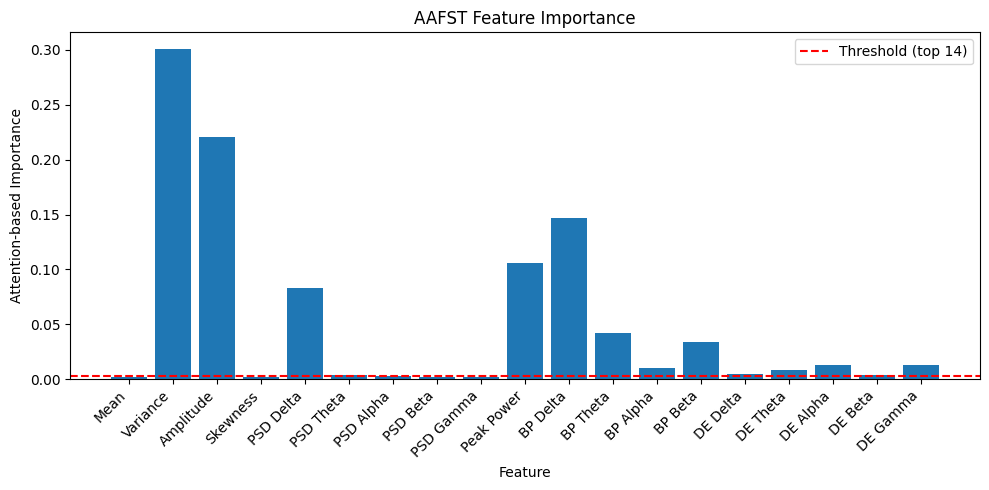

In [ ]:
# Pick one sample (first epoch) and reshape to (62, 19)
sample = X[0].reshape(C, F)  # (62, 19)

# Average across channels to get per-feature values
feature_avg = sample.mean(axis=0)  # (19,)

feature_names = [
    "Mean", "Variance", "Amplitude", "Skewness",
    "PSD Delta", "PSD Theta", "PSD Alpha", "PSD Beta", "PSD Gamma",
    "Peak Power",
    "BP Delta", "BP Theta", "BP Alpha", "BP Beta",
    "DE Delta", "DE Theta", "DE Alpha", "DE Beta", "DE Gamma"
]

plt.figure(figsize=(10, 5))
plt.bar(feature_names, importance)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Feature")
plt.ylabel("Attention-based Importance")
plt.title("AAFST Feature Importance")
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold (top 14)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

from sklearn.model_selection import GridSearchCV

param_grid = {"C": [0.1, 1, 10, 100], "gamma": ["scale", "auto"]}
grid = GridSearchCV(SVC(kernel="rbf"), param_grid, cv=5, n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV accuracy: {grid.best_score_ * 100:.2f}%")

y_pred = grid.best_estimator_.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'C': 10, 'gamma': 'scale'}
Best CV accuracy: 57.68%
Test accuracy: 59.56%


### SVM with PCA

In [ ]:
svm = SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced")
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=["Neutral","Positive","Negative","Mixed"]))

Accuracy: 59.56%
              precision    recall  f1-score   support

     Neutral       0.62      0.66      0.64       384
    Positive       0.57      0.55      0.56       387
    Negative       0.58      0.58      0.58       345
       Mixed       0.61      0.59      0.60       291

    accuracy                           0.60      1407
   macro avg       0.60      0.59      0.59      1407
weighted avg       0.59      0.60      0.59      1407



### Vanilla SVM

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Reduced from {X_train.shape[1]} to {X_train_pca.shape[1]} components")

svm = SVC(kernel="rbf", C=10, gamma="scale")
svm.fit(X_train_pca, y_train)

y_pred = svm.predict(X_test_pca)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=["Neutral","Positive","Negative","Mixed"]))

Reduced from 1178 to 93 components
Accuracy: 53.52%
              precision    recall  f1-score   support

     Neutral       0.56      0.65      0.60       384
    Positive       0.52      0.54      0.53       387
    Negative       0.50      0.47      0.48       345
       Mixed       0.56      0.45      0.50       291

    accuracy                           0.54      1407
   macro avg       0.54      0.53      0.53      1407
weighted avg       0.53      0.54      0.53      1407

